正如前面所述，LangGraph中包含的核心组件有：
- 节点（Node）：工作流中的关键工作代码，可以是工具调用、知识检索、LLM调用，用函数来定义
- 边（Edge）：也可以理解为线，就是把各个节点连接起来的路径，是控制工作流走向的关键，连接方式有：
  - 串行
  - 并行
  - 条件
- 状态（State）：整个工作流中流转的数据

由Node和Edge组成的工作流就被称为图（Graph）：
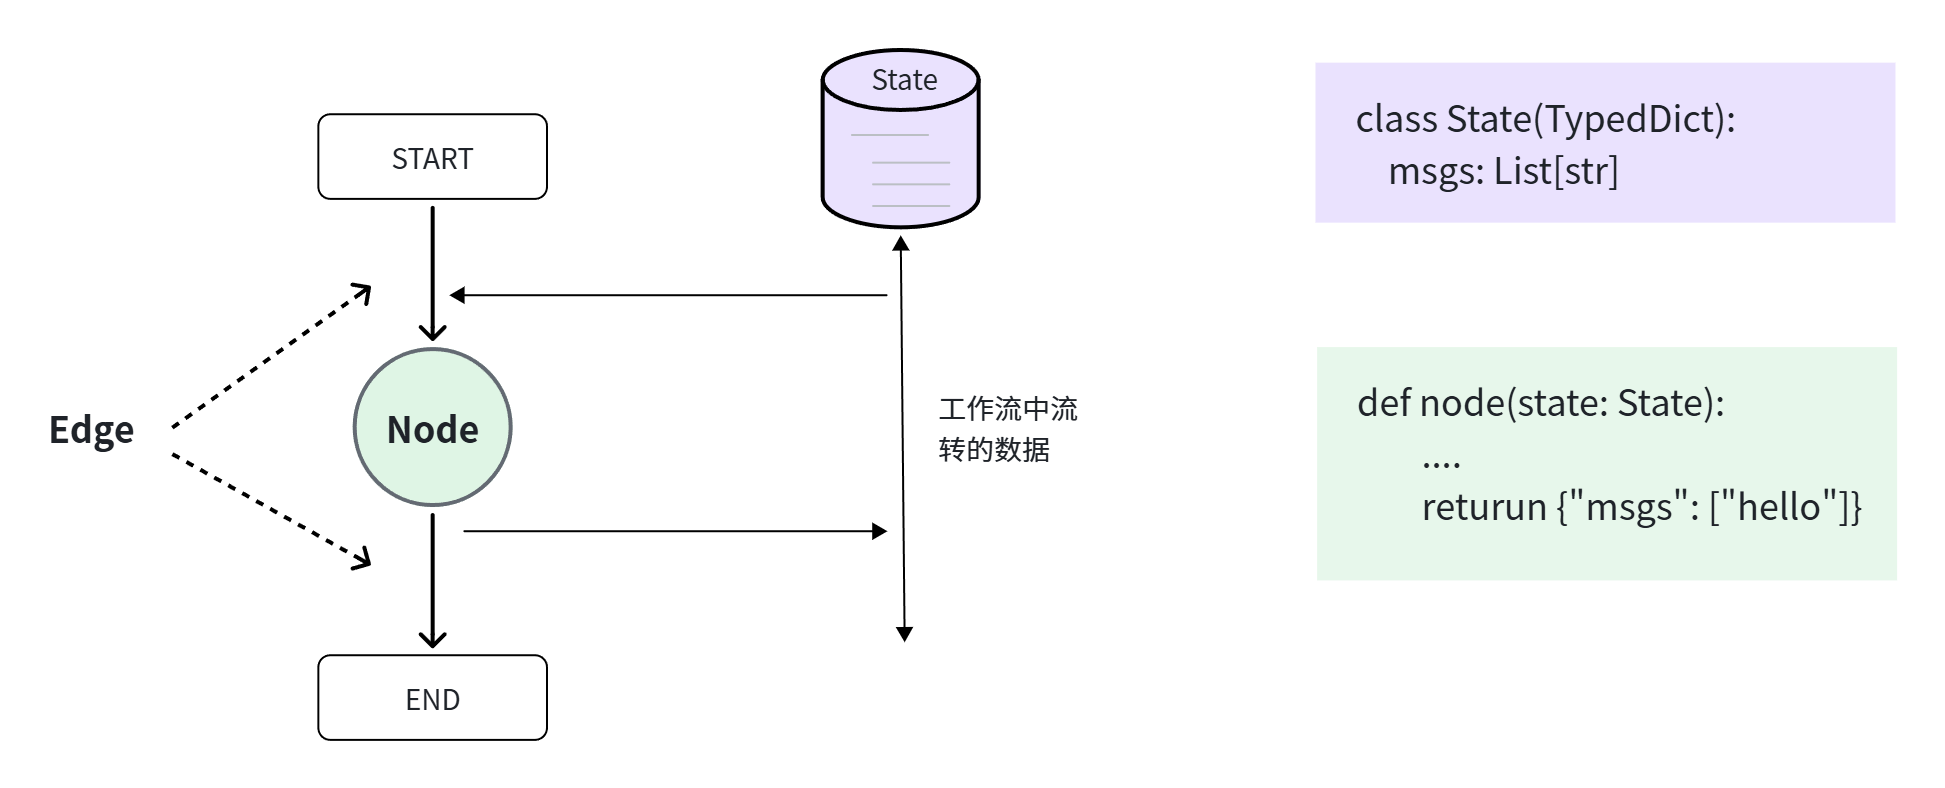
接下来，我们就逐个学习LangGraph中的这些概念，以及如何利用这些组件构成图（Graph），并自定义Agent.


以下是本节课要用到的所有依赖：

In [1]:
from typing import Annotated, TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, CachePolicy, interrupt
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy, TimeoutPolicy
from langgraph.errors import NodeError

from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display
from operator import add
from dotenv import load_dotenv
from pydantic.dataclasses import dataclass
load_dotenv()

True

## 1. 基本概念
LangGraph的核心概念有3个：Node、Edge、State

### 1.1 节点（Node）
节点（Node）是图（Graph）的执行单元，每个Node是一个Python函数。

格式如下：
```python
def my_node(state: State) -> dict:
    # 从state读取数据
    # 执行计算逻辑（可以调用LLM、工具、数据库等）
    # 返回state的更新部分（dict）
    return {"some_key": new_value}
```
- 输入：完整的State对象
- 输出：一个字典，只包含要更新的字段（部分更新）
- 可以做什么：调用LLM、执行工具、读数据库、文件操作，最终把结果更新到State中...

需要注意的是，LangGraph有两个默认的Node是无需定义的，可以直接使用：
- START：开始节点，也是入口
- END：结束节点，也是出口

例如，我们要做一个简单的Graph：
start(用户输入name) --> 节点1（生成问候语）--> 节点2（把问候语转大写）--> end

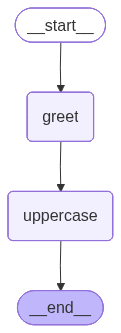

In [2]:
# 最简单的三要素示例

# 1. State: 定义共享数据结构
class SimpleState(TypedDict):
    name: str       # 记录用户name
    greeting: str   # 记录生成的问候语

# 2. Node: 定义处理逻辑
# node 1: 生成问候语的节点
def greet_node(state: SimpleState):
    """接收name，生成greeting"""
    print(f"greet_node is receiving name: {state['name']}")
    return {"greeting": f"Hello, {state['name']}!"}
# node 2: 转大写
def uppercase_node(state: SimpleState):
    """将greeting转为大写"""
    print(f"uppercase_node is receiving greeting: {state['greeting']}")
    return {"greeting": state["greeting"].upper()}

# 3. Edge: 编排执行顺序
graph_builder = StateGraph(SimpleState)             # 1.用State创建图
                                                    # 2.注册节点
graph_builder.add_node("greet", greet_node)             # greet节点
graph_builder.add_node("uppercase", uppercase_node)     # uppercase节点
                                                    # 3.创建edge，连接各个节点
graph_builder.add_edge(START, "greet")                  # START -> greet
graph_builder.add_edge("greet", "uppercase")            # greet -> uppercase
graph_builder.add_edge("uppercase", END)                # uppercase -> END

graph = graph_builder.compile()                     # 4.编译成可执行图

display(Image(graph.get_graph().draw_mermaid_png()))

测试一下（注意：调用Graph必须传入初始化的State）：

In [3]:
# 执行
result = graph.invoke({"name": "World"})
print(f"结果: {result['greeting']}")

greet_node is receiving name: World
uppercase_node is receiving greeting: Hello, World!
结果: HELLO, WORLD!


### 1.2 State（状态）

State是图的共享内存，贯穿整个执行过程。
- State定义Graph中的数据字段
- 每个Node都可以获取State数据、更新的State数据（返回要更新的字段值即可）

而Node返回数据后State的更新处理方式取决于Reducers，而且State中的每个字段都有自己的Reducer。


#### 1.2.1 默认Reducer
需要注意的是：如果字段没有指定Reducer，那默认的Reducer行为就是覆盖。

也就是说：如果多个Node都更新了State中的同一个字段，默认情况下后执行的Node将覆盖前面Node的更新结果。例如：

In [4]:
# 1. State: 定义共享数据结构，这里采用默认Reducer
class DefaultReducerState(TypedDict):
    val: str

# 2. Node: 定义处理逻辑
def node_1(state: DefaultReducerState):
    print(f"node_1 is receiving val: {state['val']}")
    return {"val": "node_1"}

def node_2(state: DefaultReducerState):
    print(f"node_2 is receiving val: {state['val']}")
    return {"val": "node_2"}

# 3. Edge: 编排执行顺序
default_reducer_graph = (
    StateGraph(DefaultReducerState)             # 1.用State创建图
    .add_node("node_1", node_1)      # 2.注册节点
    .add_node("node_2", node_2)
                                        # 3.创建edge，连接各个节点
    .add_edge(START, "node_1")               # START -> greet
    .add_edge("node_1", "node_2")         # greet -> uppercase
    .add_edge("node_2", END)             # uppercase -> END
    .compile()                          # 4.编译成可执行图
)

result = default_reducer_graph.invoke(DefaultReducerState(val="default"))
print(result)

node_1 is receiving val: default
node_2 is receiving val: node_1
{'val': 'node_2'}


#### 1.2.2 自定义Reducer
通过前面的例子我们就能看到默认的Reducer效果了。

如果我们不希望覆盖，则需要自定义Reducer，需要用到Annotated来定义：
- Annotated[type, reducer]

In [5]:
from operator import add
from typing import Annotated, TypedDict

class CustomReducerState(TypedDict):
    count: int                       # 这个字段没有定义Reducer，也就是默认会覆盖旧值
    nodes: Annotated[list[str], add] # 这里使用add作为Reducer，也就是会拼接结果


# 2. Node: 定义处理逻辑
def node_1(state: CustomReducerState):
    print(f"node_1 is receiving count: {state['count']}")
    return {"count": 1, "nodes": ["node_1"]} # 直接修改nodes值，不用自己拼接

def node_2(state: CustomReducerState):
    print(f"node_2 is receiving count: {state['count']}")
    return {"count": 2, "nodes": ["node_2"]} # 直接修改nodes值，不用自己拼接

# 3. Edge: 编排执行顺序
custom_reducer_graph = (
    StateGraph(CustomReducerState)             # 1.用State创建图
    .add_node("node_1", node_1)      # 2.注册节点
    .add_node("node_2", node_2)
                                        # 3.创建edge，连接各个节点
    .add_edge(START, "node_1")               # START -> greet
    .add_edge("node_1", "node_2")         # greet -> uppercase
    .add_edge("node_2", END)             # uppercase -> END
    .compile()                          # 4.编译成可执行图
)

result = custom_reducer_graph.invoke(CustomReducerState(count=0, nodes=[]))
print(result)

node_1 is receiving count: 0
node_2 is receiving count: 1
{'count': 2, 'nodes': ['node_1', 'node_2']}


### 1.3 Edge（边）
Edge定义节点的执行顺序。LangGraph提供两种Edge：
| 边类型 | 方法 | 说明 |
| --- | --- | --- |
| 普通边（Normal Edge） | add_edge(node_a, node_b) | 固定流向：A执行完一定到B |
| 条件边（Conditional Edge） | add_conditional_edges(node_a, router, mapping) | router的返回值决定下一节点 |
示意图：
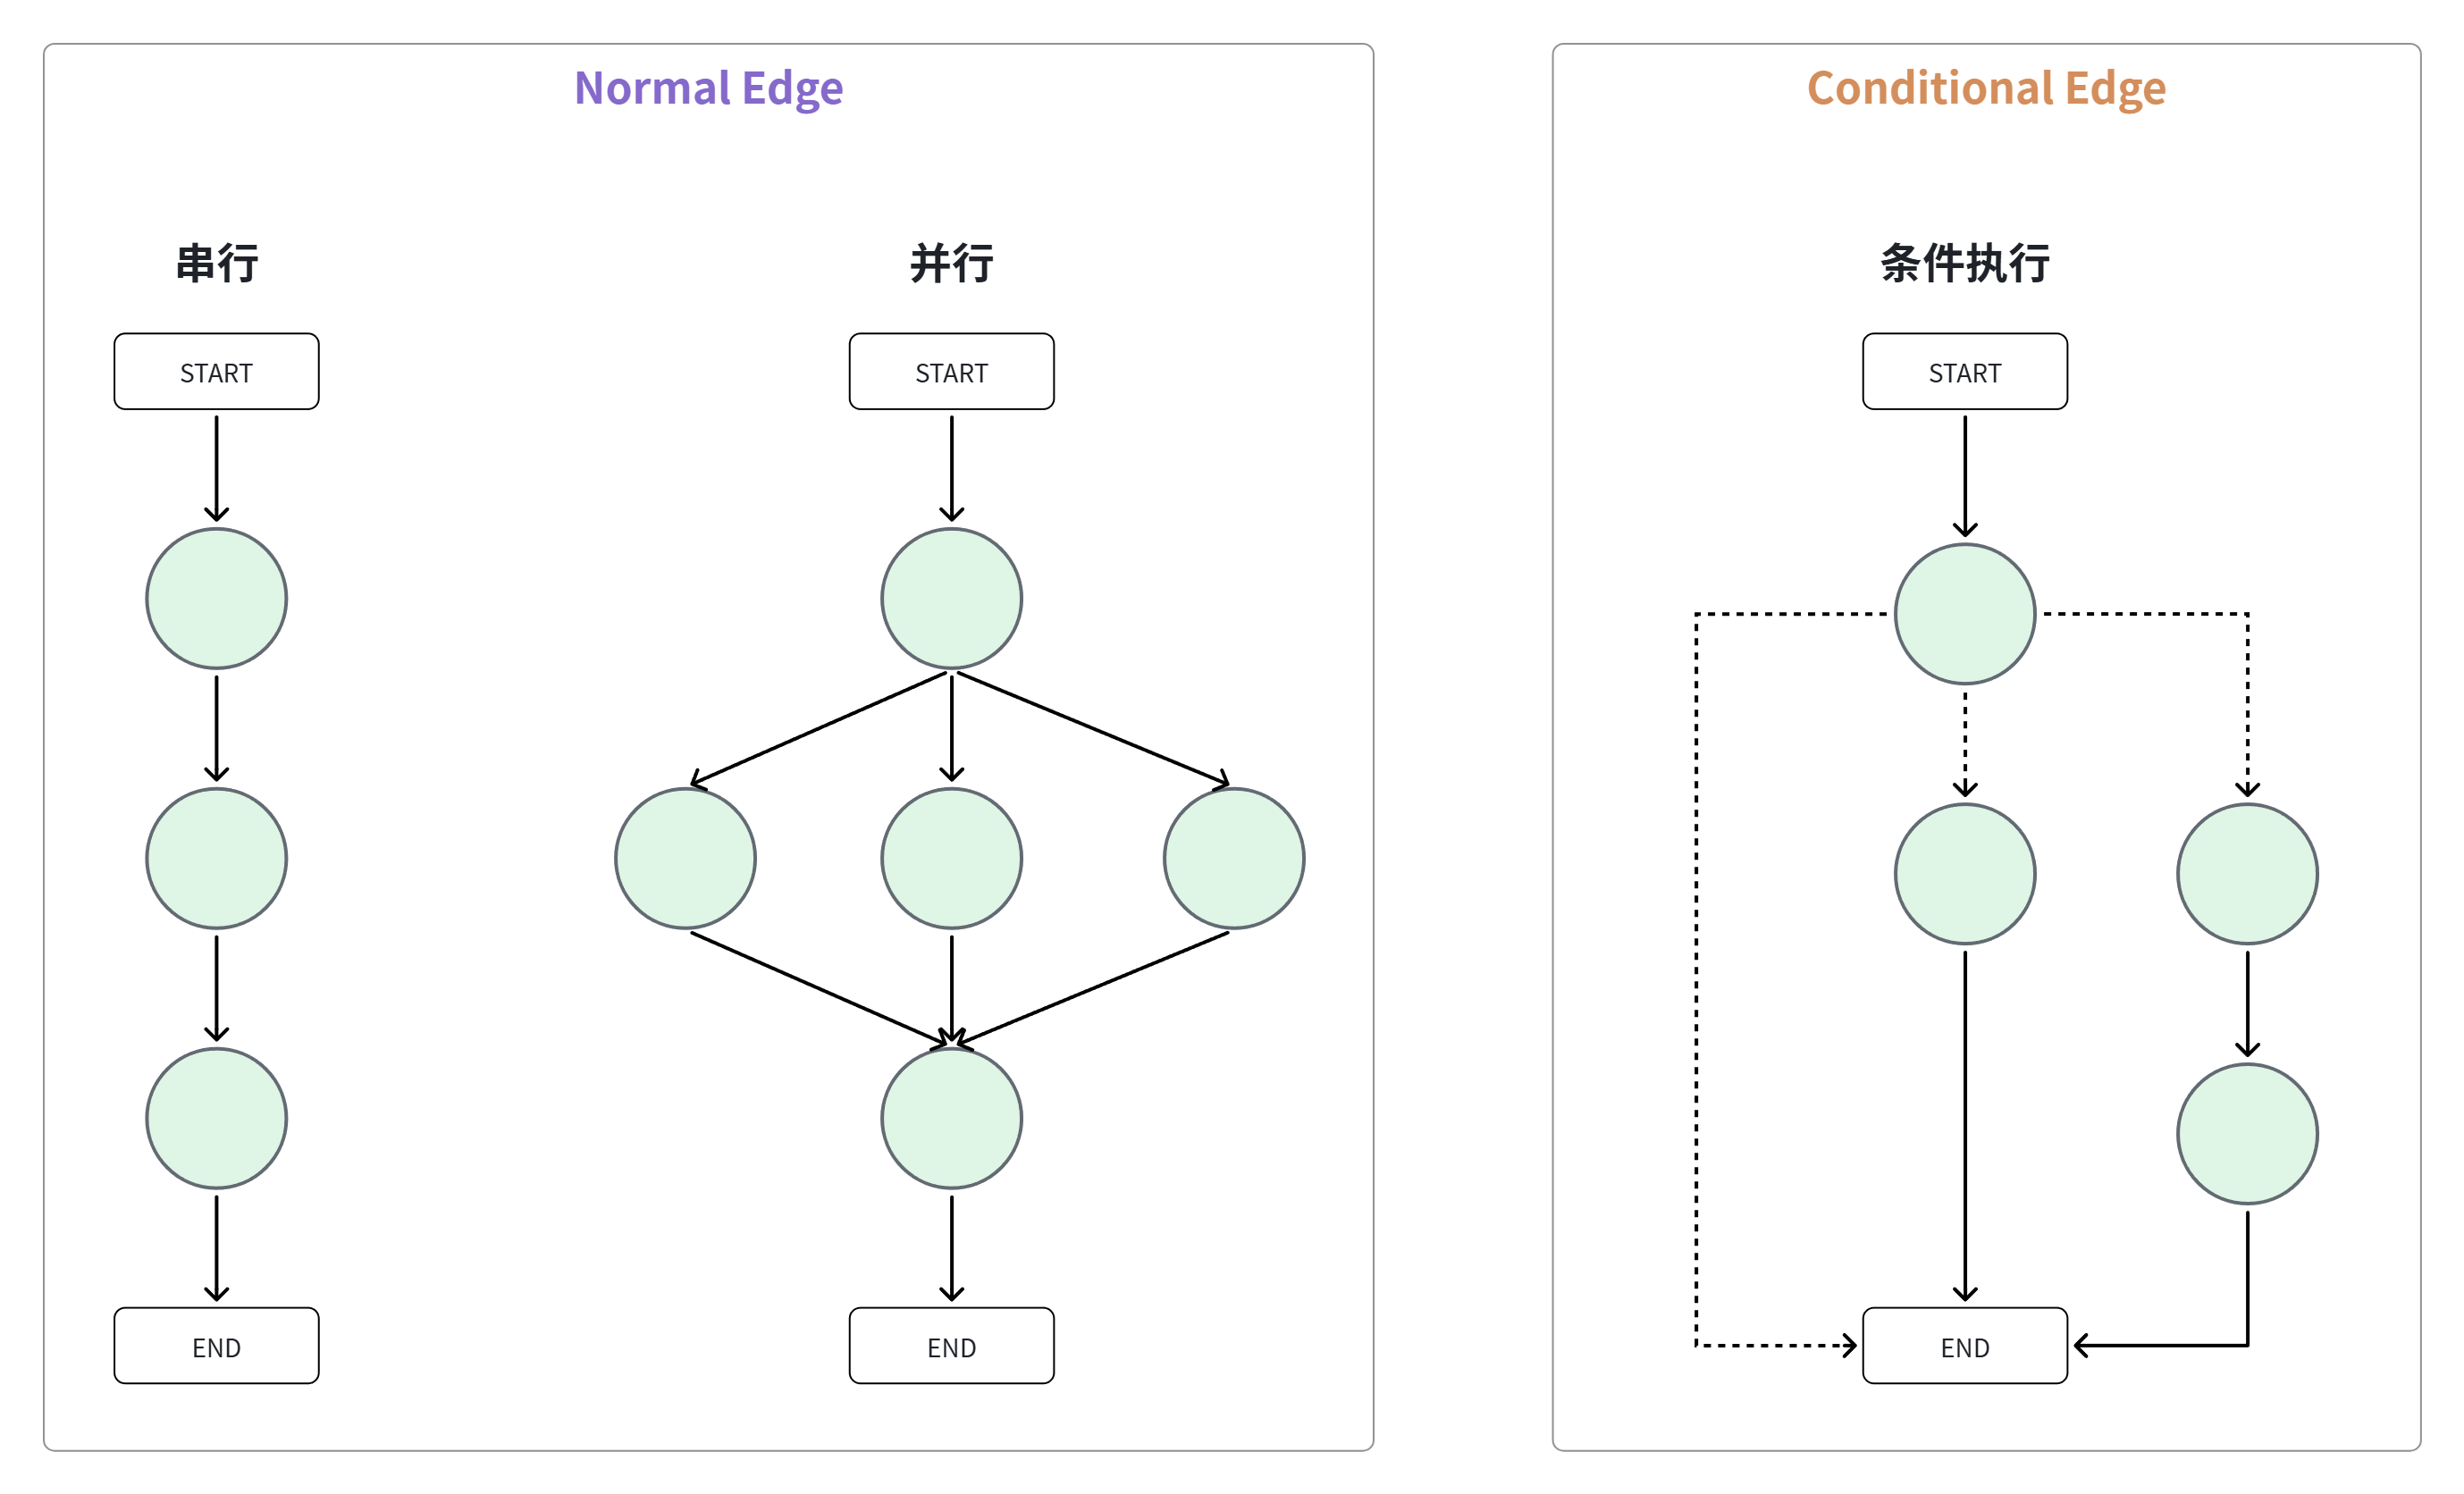

#### 1.3.1 Normal Edge
普通边连接的两个节点流向是固定的，前一个节点执行完一定会执行后一个节点。不同之处在于节点之间是串行还是并行：
- 串行: 整个工作流只有一条路径，路径中的节点按照顺序依次执行
- 并行: 整个工作流由多条路径，不同路径可以同时执行

上节我们演示的就是串行方式，本节课我们再来看看并行方式，结构如图：
```
      ┌──>  b ───┐
a ────┤          ├────> d
      └──>  c ───┘
```

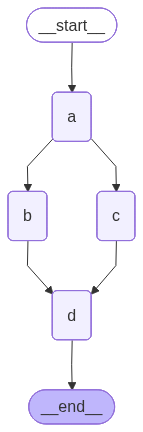

In [6]:
class ParallelState(TypedDict):
    nodes: Annotated[list[str], add]

def node_a(state: ParallelState):
    print(f"node_a is running, nodes: {state['nodes']}")
    return {"nodes": ["a"]}


def node_b(state: ParallelState):
    print(f"node_b is running, nodes: {state['nodes']}")
    return {"nodes": ["b"]}

def node_c(state: ParallelState):
    print(f"node_c is running, nodes: {state['nodes']}")
    return {"nodes": ["c"]}

def node_d(state: ParallelState):
    print(f"node_d is running, nodes: {state['nodes']}")
    return {"nodes": ["d"]}

parallel_graph = (
    StateGraph(ParallelState)
        .add_node("a", node_a)
        .add_node("b", node_b)
        .add_node("c", node_c)
        .add_node("d", node_d)
        .add_edge(START, "a") # start -> a
        .add_edge("a", "b")   # a -> b
        .add_edge("a", "c")   # a -> c
        .add_edge("b", "d")   # b -> d
        .add_edge("c", "d")   # c -> d
        .add_edge("d", END)   # d -> end
        .compile()
)

display(Image(parallel_graph.get_graph().draw_mermaid_png()))

In [7]:
result = parallel_graph.invoke(ParallelState(nodes=[]))
print(result)

node_a is running, nodes: []
node_b is running, nodes: ['a']
node_c is running, nodes: ['a']
node_d is running, nodes: ['a', 'b', 'c']
{'nodes': ['a', 'b', 'c', 'd']}


#### 1.3.2 Conditional Edge
条件边的添加方式如下：
```python
add_conditional_edges(node_a, router, mapping)
```
接收三个参数：
- node_a：是当前节点
- router：路由函数，逻辑自定义，它的返回值默认就是下个节点的名字。
- mapping：如果router返回值与下个节点名不一样，可以用mapping定义返回值与下个节点名字的映射关系

router可以根据情况返回不同的结果，但一次只能有一个结果。也就是说Conditional Edge连接的多个节点有且只有1个会成为next_node。

例如，我们实现一个成绩判定的Graph，用户输入一个分数，我们根据分数判断走哪个节点：
- 大于60，走成功节点
- 小于60，走失败节点
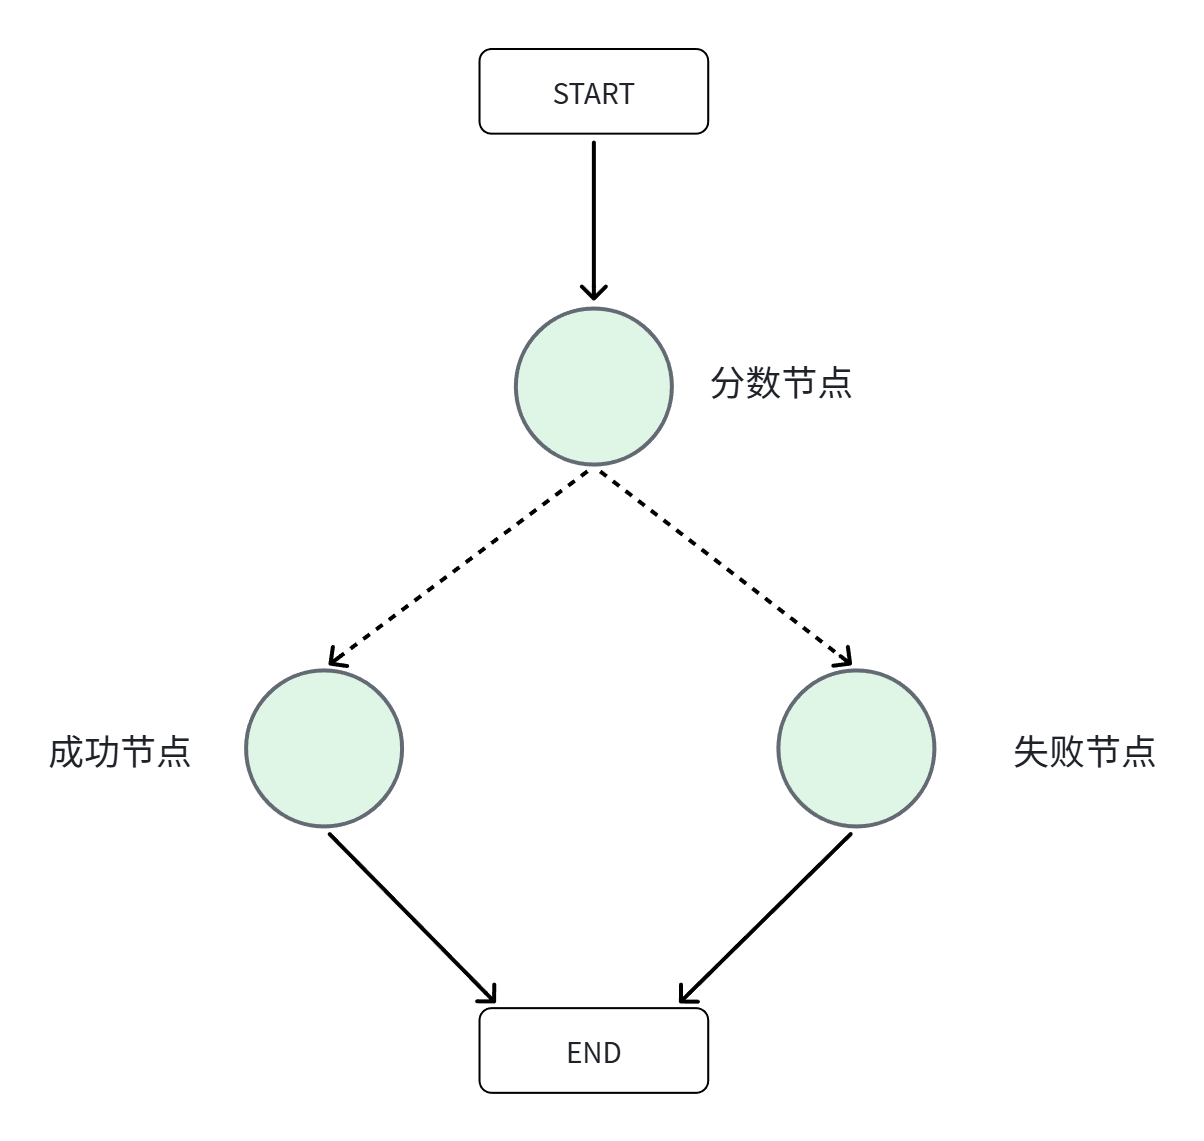

In [8]:
# 条件边示例：根据state决定走哪条路
class RouteState(TypedDict):
    score: int
    result: str

def scorer(state: RouteState):
    score = int(input("请输入分数:"))
    print(score)
    return {"score": score}  # 模拟评分

def pass_node(state: RouteState):
    return {"result": "通过！"}

def fail_node(state: RouteState):
    return {"result": "不通过"}

def router(state: RouteState) -> Literal["pass", "fail"]:
    """根据score决定下一节点"""
    if state["score"] >= 60:
        return "pass"
    return "fail"

condition_graph = (
    StateGraph(RouteState)          # 1.创建Graph
                                    # 2.添加节点
    .add_node("scorer", scorer)         # 打分节点
    .add_node("pass", pass_node)        # 失败节点
    .add_node("fail", fail_node)        # 成功节点
                                    # 3.添加Edge
    .add_edge(START, "scorer")               # start -> scorer
    .add_conditional_edges("scorer", router) # scorer -> conditional_edge(router)
    .add_edge("pass", END)                   # pass -> end
    .add_edge("fail", END)                   # fail -> end
    .compile()
)
result = condition_graph.invoke({"score": 0, "result": ""})
print(f"score={result['score']} -> {result['result']}")

90
score=90 -> 通过！


#### 1.3.3 Command实现条件分支
如果不想编写Conditional Edge，也可以在Node中直接返回下个节点信息。
但是，由于Node必须返回对State的更新，而没有条件边就需要返回下个节点的名字。函数返回值只能有一个。所以LangGraph就提供了Command API，用Command来指定下个节点以及要更新的字段。
```python
def node_a(state: State) -> Command[Literal['node_b', 'node_c']]:
    # ...
    return Command(
        update={"k":"v"},
        goto="node_b"
    )
```
其中：
- update : 用来指定要更新的State字段
- goto : 用来指定下个节点

还是刚才的例子，我们用Command来实现：

In [9]:
# 在Node中基于Command实现条件分支

class RouteState(TypedDict):
    score: int
    result: str

def scorer(state: RouteState) -> Command[Literal["fail", "pass"]]:
    score = int(input("请输入分数:"))

    next_node = "pass" if score >= 60 else "fail"

    return Command(
        update=RouteState(score = score), # 通过update更新State字段
        goto=next_node                    # 通过goto指定下个Node
    )

def pass_node(state: RouteState):
    return {"result": "通过！"}

def fail_node(state: RouteState):
    return {"result": "不通过"}

command_condition_graph = (
    StateGraph(RouteState)          # 1.创建Graph
                                    # 2.添加节点
    .add_node("scorer", scorer)         # 打分节点
    .add_node("pass", pass_node)        # 失败节点
    .add_node("fail", fail_node)        # 成功节点
                                    # 3.添加Edge
    .add_edge(START, "scorer")               # start -> scorer
    .add_edge("pass", END)                   # pass -> end
    .add_edge("fail", END)                   # fail -> end
    .compile()
)

result = command_condition_graph.invoke({"score": 0, "result": ""})
print(f"score={result['score']} -> {result['result']}")

score=99 -> 通过！


## 2. LangGraph构建Agent

学会了用LangGraph的基本概念，以及如何创建Graph，接下来我们就可以用LangGraph从零构建一个Agent了。

2.1 基础LLM调用工作流
让我们先从最基本的LLM调用开始，先不要工具。

工作流是这样的：
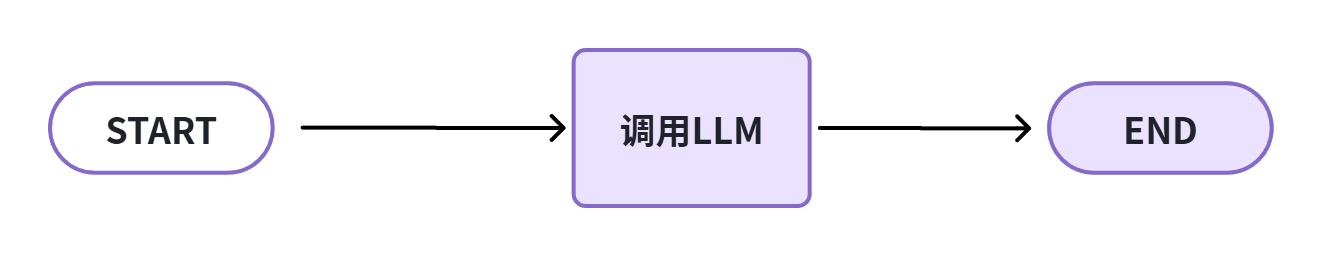

In [10]:
# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义State，记录用户输入和LLM返回的结果
class SimpleAgentState(TypedDict):
    user_input: str
    result: str

# 3.定义LLM调用Node
def call_llm(state: SimpleAgentState):
    # 调用llm，得到结果
    response = llm.invoke(state['user_input'])
    # 更新state
    return {"result": response.content}

# 4.创建Graph
llm_graph = (
    StateGraph(SimpleAgentState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)
result = llm_graph.invoke(SimpleAgentState(user_input="你好", result=""))
print(result)

{'user_input': '你好', 'result': '你好！很高兴见到你。有什么我可以帮你的吗？'}


### 2.2 消息历史
目前的Graph中，State比较简单，只记录了两个值：
- user_input: 一次用户输入
- result: 一次LLM结果
然后实际在复杂的Agent中，用户会多次与LLM交互，还有工具调用，产生大量的历史消息，这些消息都需要记录下来。因此，我们的State需要重新设计。
#### 2.2.1 自定义消息历史State
在之前学习LangChain时我们知道，Agent交互时的消息类型有很多：SystemMessage、AIMessage、HumanMessage、ToolMessage等。而这些消息都有一个共同的父类：BaseMessage。

因此，我们可以在State中定义一个字段，类型为list[BaseMessage]。但这还不够，由于要不断添加新的消息到这个list，所以还需要一个Reducer，而LangChain正好提供了这样的一个Reducer：add_message

示例：

In [11]:
from langgraph.graph.message import add_messages
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)

class MessageAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

add_message这个Reducer的效果就是不断累积消息，形成Message列表：

In [12]:
messages = [SystemMessage(content="你是一个热心助人的AI助手，你的名字叫武藏")]
messages = add_messages(messages, HumanMessage(content="你好，你是谁？"))
print(messages)

[SystemMessage(content='你是一个热心助人的AI助手，你的名字叫武藏', additional_kwargs={}, response_metadata={}, id='0a89607a-b0b3-4254-b42d-4ead4577bea6'), HumanMessage(content='你好，你是谁？', additional_kwargs={}, response_metadata={}, id='a65bced5-1690-4a09-9c9b-914f38873941')]


In [13]:
from langgraph.graph.message import add_messages

class MessageAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessageAgentState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
llm_graph = (
    StateGraph(MessageAgentState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)

result = llm_graph.invoke({"messages": messages})
print(result)

{'messages': [SystemMessage(content='你是一个热心助人的AI助手，你的名字叫武藏', additional_kwargs={}, response_metadata={}, id='0a89607a-b0b3-4254-b42d-4ead4577bea6'), HumanMessage(content='你好，你是谁？', additional_kwargs={}, response_metadata={}, id='a65bced5-1690-4a09-9c9b-914f38873941'), AIMessage(content='你好呀！我叫武藏，是一个热心助人的AI助手。有什么需要我帮忙的吗？随时告诉我，我会尽力为你解决任何问题！😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 21, 'total_tokens': 53, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 21}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'bbf3834c-5d3a-4adf-b7ae-a8324fe89c22', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea230-5e1e-7ac1-b5e5-17b3cc4a6c8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 

怎么样，熟悉的味道又回来了，这个返回值是不是跟LangChain的Agent返回值一模一样呢？

没错，因为LangChain的create_agent正是基于LangGraph实现的~

#### 2.2.2 默认的MessageState
事实上，记录Agent消息的场景非常常见，所以LangGraph中还提供了一个默认的State，专门用来记录消息历史，叫做MessageState：
```python
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```
可以看到其结构与我们自定义的非常相似，只是消息类型改成了AnyMessage，它可以看做是所有消息的统一类型。

所以，如果只是为了记录消息历史，我们可以不用定义State了，直接用MessageState：

In [ ]:
from langgraph.graph.message import add_messages, MessagesState

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessagesState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
llm_graph = (
    StateGraph(MessagesState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)
result = llm_graph.invoke({})
print(result)

### 2.3 会话记忆
有了历史并不等于有记忆，记忆必须基于会话id(thread_id)来分别管理会话历史。这就要靠LangGraph中的Checkpointer来实现了。

之前在LangChain中我们就是导入的LangGraph提供的Checkpointer来实现记忆的，这里也一样。我们用默认的InMemorySaver来演示。

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessagesState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
memory_graph = (
    StateGraph(MessagesState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile(checkpointer=InMemorySaver()) # 注意，在compile时指定Checkpointer
)

# 4.测试
# 依然要通过config中的thread_id来区分不同会话
config = {"configurable": {"thread_id": "1"}}
result = memory_graph.invoke(
    {"messages": [HumanMessage("你好，我是虎哥")]},
    config
)
result = memory_graph.invoke(
    {"messages": [HumanMessage("我是谁?")]},
    config
)
print(result)

### 2.4 带工具调用的LLM工作流
Agent通常是绑定了工具的LLM。它没有固定的工作流，而是采用ReAct行为模式：
1. 把问题交给LLM处理（Reasoning）
  1. 判断是否需要调用工具
  2. 要调用哪个工具
2. 调用工具（Action）
3. 拿到工具结果，返回结果给LLM，判断是否能回答问题（回到1）
4. 生成响应，结束

如果我们把"调用LLM"、"工具执行"，都看做是Node，那节点的流转就是由LLM控制的，动态循环的过程。
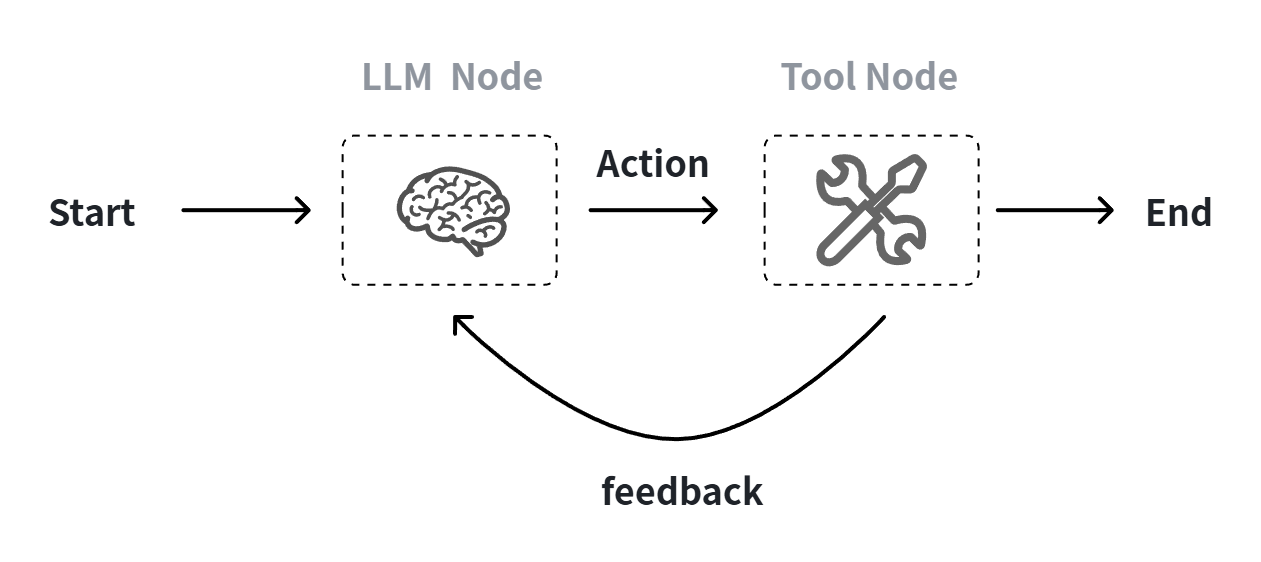

#### 2.4.1 定义Tool

In [15]:
from langchain.tools import tool
# ====== Step 1: 准备工具和模型 ======
# 工具
@tool
def get_weather(city: str) -> str:
    """获取城市天气"""
    weather_data = {
        "北京": "晴天 25度",
        "上海": "多云 28度",
        "杭州": "小雨 22度",
    }
    return weather_data.get(city, f"未找到{city}的天气信息")

@tool
def square_root(x: float) -> str:
    """Calculate the square root of a number"""
    return x ** 0.5

# 组成工具数组
tools = [get_weather, square_root]
# 组成工具名和工具的映射，方便查找工具
tools_by_name = {t.name: t for t in tools}
# 定义模型
model = init_chat_model("deepseek-chat")
# 绑定工具到模型
model_with_tools = model.bind_tools(tools)


需要注意的，手动调用带工具的模型，模型会返回要执行的工具的信息，我们需要解析这些信息，拿到要调用的工具名称和参数，自己去调用。
所以，我们才在上面建立了工具name与工具的映射。
另外，等一下定义Node的时候就需要自己调用Tool.

#### 2.4.2 定义Node

In [ ]:

# ====== Step 2: 定义Node函数 ======
def llm_node(state: MessagesState):
    """LLM节点：调用模型，可以选择调用工具"""
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def tool_node(state: MessagesState):
    """工具节点：执行LLM要求的工具调用"""
    last_message = state["messages"][-1]
    results = []
    # AI可能一次返回多个工具调用，所以需要循环处理，再收集结果
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        results.append(ToolMessage(
            content=result,
            tool_call_id=tool_call["id"]
        ))
    return {"messages": results}

def should_continue(state: MessagesState) -> Literal["tools", END]:
    """路由函数：判断下一步是继续调工具还是结束"""
    last_message = state["messages"][-1]
    # 如果包含tool_calls，则跳转到tools节点，没有则跳转到END节点
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"  # 有工具调用 -> 去工具节点
    return END           # 没工具调用 -> 结束

print("Step 2 完成: Node函数已定义")

#### 2.4.3 构建Graph

In [ ]:
# ====== Step 3: 构建图 ======
agent_graph = (
    StateGraph(MessagesState)
    .add_node("llm", llm_node)
    .add_node("tools", tool_node)
    .add_edge(START, "llm")
    .add_conditional_edges("llm", should_continue)
    .add_edge("tools", "llm")  # 工具执行后回到LLM，形成循环
    .compile()
)

display(Image(agent_graph.get_graph().draw_mermaid_png()))

测试：

In [ ]:
# ====== Step 4: 测试 ======
print("测试1: 不需要工具调用\n")
result = agent_graph.invoke({
    "messages": [HumanMessage(content="你好")]
})
for m in result['messages']:
    m.pretty_print()

In [ ]:
print("测试2: 需要工具调用\n")
result = agent_graph.invoke({
    "messages": [HumanMessage(content="北京今天天气怎么样？")]
})
for m in result['messages']:
    m.pretty_print()

### 2.5 Runtime Context
在LangGraph中同样支持Runtime Context功能，方式也完全一样：
- 定义ContextSchema
- 创建Graph时指定state、context_schema、store等Runtime

示例：

In [16]:
from pydantic.dataclasses import dataclass

@dataclass
class ContextSchema:
    reasoning: str = "enable" # 是否开启思考模式

# 1.先初始化一个模型，比如DeepSeek
llm = init_chat_model("deepseek-v4-flash")

# 2.定义LLM调用Node
def call_llm(state: MessagesState, runtime: Runtime[ContextSchema]):
    # 调用llm，得到结果
    response = llm.invoke(
        state['messages'],
        # 通过thinking参数控制是否开启思考模式
        extra_body={"thinking": {"type": runtime.context.reasoning}}
    )
    print("调用llm")
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
context_graph = (
    StateGraph(MessagesState, context_schema=ContextSchema)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)

# 4.调用Graph，传递context信息
result = context_graph.invoke(
    {"messages": [HumanMessage(content="你是谁？")]},
    context = {"reasoning": "disabled"}
)
print(result)

调用llm
{'messages': [HumanMessage(content='你是谁？', additional_kwargs={}, response_metadata={}, id='a4cedb99-aefc-453c-8382-29b5aacf4dee'), AIMessage(content='你好！我是DeepSeek，由深度求索公司创造的AI助手。我是一个纯文本模型，专门用来回答问题、提供信息和帮助解决问题。\n\n我的一些特点包括：\n- **免费使用**：完全免费，没有收费计划\n- **强大的上下文能力**：支持1M超长上下文，可以一次性处理像《三体》三部曲那么大体量的内容\n- **文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文件，并从中读取文字信息\n- **联网搜索**：支持联网搜索功能（需要手动开启）\n- **多平台**：有Web版和App版（支持语音输入）\n\n我的知识截止日期是2025年5月，会尽力以热情、细腻的方式帮助你解决问题。有什么我可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 167, 'prompt_tokens': 6, 'total_tokens': 173, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 6}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '4456d977-ebc2-4e97-aa68-41fad35f0521', 'finish_reason': 'stop', 'logprobs': None}

### 2.6 节点缓存(Node Cache)
LangGraph还提供了节点级别的缓存功能。当请求进入节点时，会根据节点输入的参数生成key，以key和节点的输出建立缓存。如果下次key命中，则直接返回结果而不用再执行该节点的逻辑。

要使用节点缓存需要两步：
- 在编译Graph时指定缓存实现方式，LangGraph提供了InMemoryCache、RedisCache、SqliteCache
- 为节点指定缓存策略。每个缓存策略支持：
  - Key_func：函数，用于根据节点的输入生成缓存键，默认为带有pickle的输入参数的hash值。
  - ttl：缓存的有效时间，以秒为单位。如果没有指定，缓存将永远不会过期。

In [17]:
from typing import Any
from langgraph.cache.memory import InMemoryCache

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessagesState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    print("调用llm")
    # 更新state
    return {"messages": [response]}

def my_cache_key(*args: Any, **kwargs: Any) -> str | bytes:
    """把用户的消息作为key，消息一样则缓存命中"""
    msgs = args[0]['messages']
    return msgs[0].content if msgs and len(msgs) > 0 else "0"

# 3.创建Graph
cache_graph = (
    StateGraph(MessagesState)
    .add_node("llm", call_llm, cache_policy=CachePolicy(key_func=my_cache_key))
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile(cache = InMemoryCache())
)

测试：

In [18]:
# 4.测试
result = cache_graph.invoke(
    {"messages": [HumanMessage(content="你好")]}
)
print(result)

调用llm
{'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='8cba6ff6-4e2b-42a6-afca-1b4c16c68414'), AIMessage(content='你好！很高兴见到你。有什么可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 5, 'total_tokens': 19, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 5}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '7497c1da-781b-43a0-a300-f48662e91072', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea234-7de4-71a3-a505-2711a1c12914-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 14, 'total_tokens': 19, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})]}


In [19]:
result = cache_graph.invoke(
    {"messages": [HumanMessage(content="你好")]},
)
print(result)

{'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='c9a955fe-0836-4e64-858a-e5af73678ebd'), AIMessage(content='你好！很高兴见到你。有什么可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 5, 'total_tokens': 19, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 5}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '7497c1da-781b-43a0-a300-f48662e91072', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea234-7de4-71a3-a505-2711a1c12914-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 14, 'total_tokens': 19, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})]}


会发现第二次调用几乎是一瞬间就结束了，而且没有打印"调用LLM"，说明缓存命中了。

### 2.7 失败容错
当一个节点发生故障时，比如：外部API超时、临时网络异常、其它未处理的异常时，langgraph提供了三种可组合的失败容错机制：

- 重试（Retries）-根据异常类型和回退设置自动重新运行失败的尝试
- 超时（Timeouts）-限制单个尝试可能运行的时间
- 错误处理（Error handling）-在所有重试用尽后的降级处理策略
你可以使用set_node_defaults可以为所有Node统一配置这些机制，也可以每次调用add_node时单独配置。

它们以固定的顺序组合：当节点尝试运行引发任何异常（包括超时的NodeTimeoutError）时，Retries策略决定是否重试。只有在重试失败后才运行Error handling。
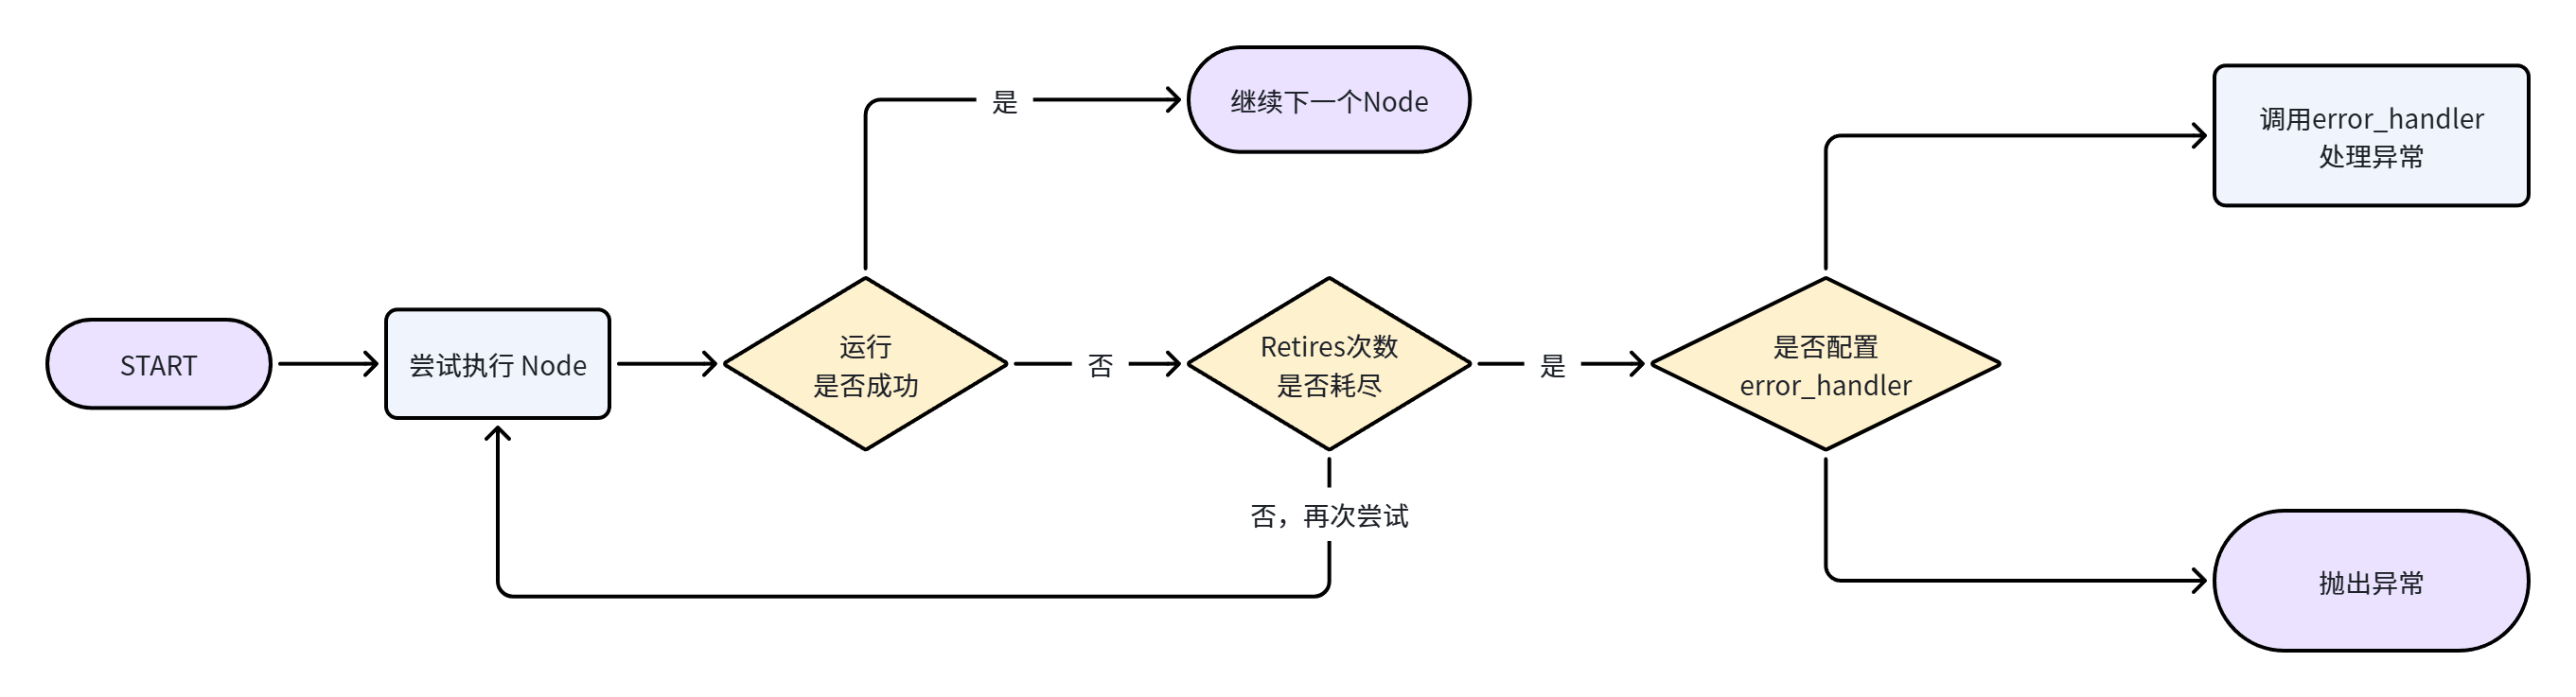
**注意**：要设置timout参数必须保证Node的函数是异步（aysnc）的，否则会报错。

In [20]:
# 1.先初始化一个模型
llm = init_chat_model("gpt-3.5-turbo")

async def llm_node(state: dict, runtime):
    print(f"调用llm ... 第 {runtime.execution_info.node_attempt} 次")
    # timeout要求一定要使用异步调用
    response = await llm.ainvoke(state['messages'])
    return {"messages": [response]}

async def default_error_handler(state: MessagesState, error: NodeError) -> Command:
    print(f"运行异常，{error}")
    print("执行fallback逻辑...")
    return Command(goto=END)

builder = StateGraph(dict)
builder.add_node(
    "llm",
    llm_node,
    timeout=TimeoutPolicy(idle_timeout=3),
    retry_policy=RetryPolicy(max_attempts=3),
    error_handler=default_error_handler
)
builder.add_edge(START, "llm")
builder.add_edge("llm", END)
fail_tolerance_graph = builder.compile()

# 运行测试
result = await fail_tolerance_graph.ainvoke({"messages": [HumanMessage("你好")]})
print(result)

调用llm ... 第 1 次
调用llm ... 第 2 次
调用llm ... 第 3 次
运行异常，NodeError(node='llm', error=AuthenticationError("Error code: 401 - {'error': {'message': 'Incorrect API key provided: xxxxx. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}"))
执行fallback逻辑...
{'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={})]}


### 2.8 Streaming
LangGraph中的streaming方式与LangChain的Agent一样：
```python
for chunk, metadata in agent_graph.stream(
    {"messages": [{"role": "user", "content": "429和517的平方根是多少?"}]},
    stream_mode="messages"
):
    content = chunk.content
    if content:
        print(content, end="", flush=True)
```
不过，LangGraph > 1.2.0版本后提供了Stream的3.0版本，推荐使用stream_events方式实现streaming：
- 使用graph.stream_events方法实现stream调用
- 需要在参数中指定version="v3"
与LangChain中的v2版本不同，调用stream_events不会返回Iterator，而是返回一个GraphRunStream类，你可以自己选择想要通过stream获取的内容：
- stream :  Iterate every protocol event.
- stream.messages : Stream chat model messages and token deltas.
- stream.values :   Iterate state snapshots and await the final value.
- stream.output :   Await the final output.
- stream.subgraphs :    Discover and observe nested graph executions.
- stream.interrupts : Inspect human-in-the-loop interrupt payloads.
- stream.interrupted :  Check whether the run paused for human input.
- stream.extensions : Consume custom stream transformer projections.
```python
# 先拿到stream
stream = agent_graph.stream_events({
    "messages": [{"role": "user", "content": "429和517的平方根是多少?"}],
}, version="v3")

# 再通过stream.messages拿到一个messages片段的Iterator
for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)
```
不仅如此，各种不同的消息模式还互补影响。

比如，刚刚通过stream.message以token形式获取消息后，我们还可以继续拿最终完整结果：
```
# 直接获取最终的完整结果
final_state = stream.output
for m in final_state['messages']:
    m.pretty_print()
```

### 2.9 Interrupts
中断(Interrupts)允许您在特定Node暂停Graph执行，并在继续之前等待外部输入。利用这个特性，就能实现“Human In The Loop”模式，把一些重要决断交给人工来做。

当中断被触发时，LangGraph使用它的Checkpointer保存Graph的State，并无限期地等待，直到恢复执行。

你可以在Graph的任何Node调用interrupt()函数来中断工作。该函数接受向调用者显示的任何json可序列化的值。
当您准备好继续时，您可以通过使用Command(resume={})重新调用Graph来恢复执行，而resume值将成为节点内部interrupt()调用的返回值。

一定要注意：断点恢复必须指定thread_id，它是找到不同会话Checkpointer的关键。

我们还是用之前讲过的邮件助手为例：

In [ ]:
# ====== Step 1: 定义各种工具 ======
@tool
def check_inbox() -> str:
    """Read an email from the given address."""
    # 模拟收件箱邮件
    return [
        {
            "subject": "周末见个面？",
            "content": """
                嗨 虎哥，
                我下周会去城里，不知道我们有没有机会一起喝杯咖啡？

                祝好，简
            """,
            "from": "jane@itcast.cn",
            "status": "unread"
        },
        {
            "subject": "周五会议",
            "content": """
                嗨 虎哥，
                非常抱歉，我周五的会议无法准时参加了，能不能重新安排个时间？

                祝好，小李
            """,
            "from": "lixiaolong@itcast.cn",
            "status": "checked"
        }
    ]


@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an response email"""
    human_decision = interrupt({
        "args": {
            "to": to,
            "subject": subject,
            "body": body,
        },
        "confirm": "这是我帮你写的邮件，你觉得如何？",
        "actions": ["reject", "approve", "edit"]
    })
    decision = human_decision.get("action")
    if decision == "approve":
        return f"邮件已发送至 {to} , 主题： {subject} , 内容： {body}"
    elif decision == "reject":
        return f"用户拒绝发送：{human_decision.get("reason")}"
    else: # 修改邮件了，需要读取邮件内容
        body = human_decision['args']['body']
        return f"邮件已发送至 {to} , 主题： {subject} , 内容： {body}"

# 组成工具数组
tools = [check_inbox, send_email]
# 组成工具名和工具的映射，方便查找工具
tools_by_name = {t.name: t for t in tools}

# ====== Step 2: 定义模型，绑定工具 ======
# 定义模型
model = init_chat_model("deepseek-chat")
# 绑定工具到模型
model_with_tools = model.bind_tools(tools)

# ====== Step 3: 构建图 ======
hitl_graph = (
    StateGraph(MessagesState)
    .add_node("llm", llm_node)
    .add_node("tools", tool_node)
    .add_edge(START, "llm")
    .add_conditional_edges("llm", should_continue)
    .add_edge("tools", "llm")  # 工具执行后回到LLM，形成循环
    .compile(checkpointer=InMemorySaver())
)

In [ ]:
# ====== Step 4: 测试 ======
config = {"configurable": {"thread_id": "1"}}
stream = hitl_graph.stream_events(
    {"messages": [HumanMessage("帮我查看下邮件")]},
    config = config,
    version="v3"
)

for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

In [ ]:
config = {"configurable": {"thread_id": "1"}}
stream = hitl_graph.stream_events(
    {"messages": [HumanMessage("帮我回复Jane，告诉她很高兴她能来，问问具体时间")]},
    config = config,
    version="v3"
)

for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

会发现运行后没有任何输出，这是因为调用发邮件工具时被中止了。

我们可以通过stream.interrupts来获取中断信息：

In [ ]:
interrupt_info = stream.interrupts[0].value
print(interrupt_info)

果然，这个输出信息就是send_email节点内部调用interrupt时传入的信息。

理论上接下来就是人机交互，让用户选择接下来的操作：approve/reject/edit了。

我们定义一个方法，用键盘录入模拟人机交互：

In [ ]:
# 定义收集用户指令的方法
def get_human_decision(interrupt_info: dict):
    # 这里模拟前端交互，让用户确认接下来的操作
    action = input(f"""
    subject: {interrupt_info['args']['subject']}\n
    to: {interrupt_info['args']['to']}\n
    body: {interrupt_info['args']['body']}\n
    {interrupt_info['confirm']}\n
    可选操作：{interrupt_info['actions']}
    """)
    # 判断操作是什么，返回不同的响应
    resume = {"action": action}
    if action == "approve":
        return Command(resume=resume)
    elif action == "reject":
        # 拒绝了，让用户说下修改建议
        reason = input("好的，请说明拒绝原因。")
        resume['reason'] = reason
        return Command(resume=resume)
    else:
        # 用户要修改邮件，让用户输入邮件内容：
        body = input("请输入新的邮件内容")
        resume['args']['body'] = body
        return Command(resume=resume)

# 测试，获取人工确认信息
decision = get_human_decision(interrupt_info)

# 把人的确认信息发送回Graph，回复Graph运行
stream = hitl_graph.stream_events(
    decision,
    config = config,
    version="v3"
)

for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

为了实现持续的与用户交互，我们可以写一个循环：

In [ ]:
config = {"configurable": {"thread_id": "3"}}
stream_input: dict | Command = {"messages": [HumanMessage("你好")]}

while True:
    stream = hitl_graph.stream_events(stream_input,config = config,version="v3")
    print("================🤖==================")
    for message in stream.messages:
        for token in message.text:
            print(token, end="", flush=True)
    print("")
    # 判断是否有Interrupt需要
    if not stream.interrupted:
        # 没有hitl信息，让用户接着输入
        message = input("请输入：")
        if message == "quit":
            final_state = stream.output
            break
        print("================👤==================")
        print(message)
        stream_input = {"messages": [HumanMessage(message)]}
        # 继续下次循环，调用Graph
        continue

    # 有Interrupt要处理
    interrupt_info = stream.interrupts[0].value
    # 人工介入，然后继续下次循环，就会把human_decision传给Graph
    stream_input = get_human_decision(interrupt_info)

2.10 create_agent揭秘
至此你可能会发现：手动构建的图和 create_agent 行为几乎一样。这不是巧合——create_agent 底层就是用 StateGraph 构建的。

代码对比
```
# 你写的代码：
agent = create_agent(
    model="deepseek-chat",
    tools=[get_weather, calculate],
    system_prompt="你是一个有用的助手。",
    checkpointer=InMemorySaver(),
)

# 等同于底层手写的：
agent_graph = (
    StateGraph(MessagesState)
    .add_node("llm", llm_node)
    .add_node("tools", tool_node)
    .add_edge(START, "llm")
    .add_conditional_edges("llm", should_continue, ...)
    .add_edge("tools", "llm")
    .compile(checkpointer=InMemorySaver())
)
```

create_agent 做了什么？
| 你的参数 | 底层转化 |
| --- | --- |
| model | 绑定到llm_node中 |
| tools | 注册到tool_node中，同时传给 llm.bind_tools() |
| system_prompt | 注入到llm_node的SystemMessage |
| middleware | 在llm_node前后插入before_model/after_model钩子 |
| checkpointer | 传给 graph.compile(checkpointer=...) |
| state_schema | 传给 StateGraph(YourState) |

什么时候用哪种？

| 场景 | 推荐方式 |
| --- | --- |
| 标准工具调用Agent | create_agent |
| 需要自定义Middleware | create_agent + Middleware |
| RAG、简单检索问答 | create_agent + Middleware |
| 多步骤流水线（检索→分析→总结） | 手动StateGraph |
| 条件分支（审批→执行/驳回） | 手动StateGraph |
| 并行执行（同时调用多个工具/模型） | 手动StateGraph |
| 复杂循环（多轮推理直到满足条件） | 手动StateGraph |
| 子流程嵌套 | 手动StateGraph |

原则：能用 create_agent 解决的先用它，需要自定义控制流时再用手动Graph。两者不是互斥的——你可以在Graph中嵌套 create_agent 作为子节点。